# 01 · Exploratory data analysis: MovieLens 32M

This notebook explains the choices in `params.yaml` (`preprocess` and `split`). It only *reads*
pipeline outputs (`data/interim`, `data/processed`, `metrics/`); run `uv run dvc repro` (or `dvc pull`) first.

Run it with: `uv sync --group notebook` then `uv run jupyter lab`.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from recsys.utils.config import load_params
from recsys.utils.paths import INTERIM_DIR, METRICS_DIR, PROCESSED_DIR, SPLITS_DIR

plt.rcParams.update(
    {
        "figure.figsize": (9, 3.5),
        "figure.dpi": 80,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
params = load_params()
pd.Series(json.loads((METRICS_DIR / "data_validation.json").read_text()))

first_rating                1995-01-09T11:46:44+00:00
last_rating                 2023-10-13T02:29:07+00:00
mean_rating                                    3.5404
n_movies                                        87585
n_movies_rated                                  84432
n_movies_without_tmdb_id                          124
n_ratings                                    32000204
n_tags                                        2000072
n_users                                        200948
dtype: object

## 1. Raw ratings over time
The dataset spans 1995–2023, but activity is uneven. The share of *positive* ratings (≥ 3.5) has also drifted upward over time.

,ratings,users,share_positive
year,,,
2014,518537,7101,0.692770
2015,1743866,15661,0.665010
2016,1918739,15705,0.656027
2017,1827953,14481,0.660573
2018,1391057,13114,0.664624
2019,1385467,12345,0.674716
2020,1688159,14525,0.685582
2021,1239912,12109,0.675937
2022,913105,9862,0.644297


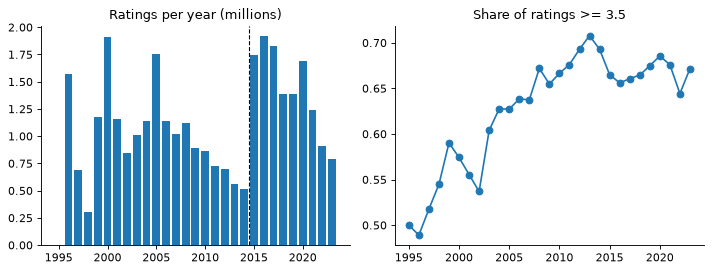

In [2]:
ratings = pd.read_parquet(
    INTERIM_DIR / "ratings.parquet", columns=["userId", "rating", "timestamp"]
)
ratings["year"] = pd.to_datetime(ratings["timestamp"], unit="s", utc=True).dt.year
by_year = ratings.groupby("year").agg(ratings=("rating", "size"), users=("userId", "nunique"))
by_year["share_positive"] = (
    ratings.assign(pos=ratings["rating"] >= 3.5).groupby("year")["pos"].mean()
)

fig, (a, b) = plt.subplots(1, 2)
a.bar(by_year.index, by_year["ratings"] / 1e6)
a.axvline(2014.5, color="k", ls="--", lw=1)
a.set_title("Ratings per year (millions)")
b.plot(by_year.index, by_year["share_positive"], marker="o")
b.set_title("Share of ratings >= 3.5")
plt.tight_layout()
by_year.tail(10)

**Why `start_date: 2015-01-01`:** activity roughly triples in 2015 versus 2014, and the later years are what a
modern app's users look like. Starting in 2010 instead adds ~25% more training data but almost no additional evaluable users
(validation: 5,840 vs 5,806), and training cost on CPU scales with data size.

## 2. Rating distribution
We treat ratings ≥ 3.5 as "liked" (implicit positive feedback) and model *what users like*, not the star value.

share >= 3.5: 63.2%


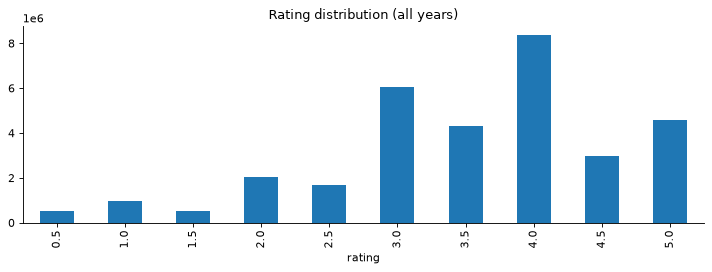

In [3]:
ax = ratings["rating"].value_counts().sort_index().plot.bar(title="Rating distribution (all years)")
ax.set_xlabel("rating")
plt.tight_layout()
print(f"share >= 3.5: {(ratings['rating'] >= 3.5).mean():.1%}")
del ratings

## 3. The processed dataset
After the window, the positive threshold, the 20k-movie cap and the k-core filter (users ≥ 5, movies ≥ 10):

In [4]:
pd.Series(json.loads((METRICS_DIR / "preprocess.json").read_text()))

density                         6.010000e-03
kept_fraction_of_raw            2.650000e-01
median_interactions_per_user    6.400000e+01
n_interactions                  8.480830e+06
n_items                         1.964200e+04
n_users                         7.184100e+04
dtype: float64

Top 1% of movies receive 34.4% of all positives


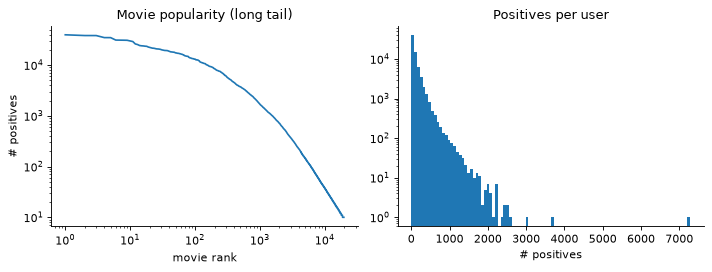

In [5]:
inter = pd.read_parquet(PROCESSED_DIR / "interactions.parquet")
item_pop = inter["item_idx"].value_counts().to_numpy()
user_act = inter["user_idx"].value_counts().to_numpy()

fig, (a, b) = plt.subplots(1, 2)
a.loglog(range(1, len(item_pop) + 1), item_pop)
a.set_title("Movie popularity (long tail)")
a.set_xlabel("movie rank")
a.set_ylabel("# positives")
b.hist(user_act, bins=100, log=True)
b.set_title("Positives per user")
b.set_xlabel("# positives")
plt.tight_layout()
top = item_pop[: len(item_pop) // 100].sum() / item_pop.sum()
print(f"Top 1% of movies receive {top:.1%} of all positives")

The long tail is why **popularity** is a strong baseline and why we track **catalog coverage** and
**novelty** alongside accuracy: a model can score well just by recommending blockbusters.

## 4. The temporal split

,frac_targets_on_unseen_items,n_interactions,n_users,n_users_with_history,n_items
test,0.0224,520897.0,8707.0,5250.0,NaN
train,NaN,7384228.0,64440.0,NaN,19166.0
val,0.0322,575705.0,9739.0,5795.0,NaN


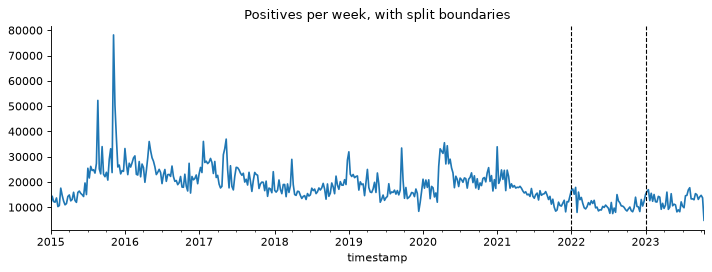

In [6]:
split = params["split"]
weekly = pd.to_datetime(inter["timestamp"], unit="s").dt.to_period("W").value_counts().sort_index()
ax = weekly.plot(title="Positives per week, with split boundaries")
for d in (split["val_start"], split["test_start"]):
    ax.axvline(pd.Period(d, "W"), color="k", ls="--", lw=1)
plt.tight_layout()
pd.DataFrame(json.loads((METRICS_DIR / "split.json").read_text())).T

**Why a global temporal split:** one cut-off date for everyone, like production, where a model trained
on the past is judged on the future. Random or leave-last-out splits let models train on interactions that happen *after* the
ones they are tested on, which inflates metrics.

**Why 2022 for validation and 2023 for test:** each has ~5k users with prior history (enough for tight confidence intervals),
and the test window is the most recent data.

**Two things to remember for evaluation (Phase 2):**
- ~40% of validation/test users have **no earlier history**. Collaborative models can't score them from history, so they're
  evaluated separately later as an *onboarding* scenario.
- ~2–3% of target interactions are on movies **never seen before the cut-off** (new releases), so no collaborative model can
  recommend them. This caps every model's achievable recall slightly below 100%.

In [7]:
train = pd.read_parquet(SPLITS_DIR / "train.parquet")
for name in ("val", "test"):
    tgt = pd.read_parquet(SPLITS_DIR / f"{name}.parquet")
    hist = (
        train if name == "val" else pd.concat([train, pd.read_parquet(SPLITS_DIR / "val.parquet")])
    )
    h = hist.groupby("user_idx").size()
    lens = h.reindex(tgt["user_idx"].unique()).dropna()
    print(
        f"{name}: history length (users with history): median {lens.median():.0f}, "
        f"<20: {(lens < 20).mean():.0%}, >=200: {(lens >= 200).mean():.0%}"
    )

val: history length (users with history): median 172, <20: 4%, >=200: 43%


test: history length (users with history): median 188, <20: 4%, >=200: 47%


The wide spread of history lengths is why results are also reported **per segment** (short vs long histories).